In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown as md
import time as time

beep = lambda x: os.system("echo -n '\a';sleep 0.2;" * x)

In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [3]:
# Make graphs large enough to read easily
plt.clf()
plt.rcParams["figure.figsize"] = [10.0, 10.0*2/3]
matplotlib.rcParams["font.size"] = 20
None

<Figure size 432x288 with 0 Axes>

In [4]:
display(md("### load the code"))
%run ../gui/wja_caen_tcal
tbegin = time.time()

### load the code

wja_caen_tcal.py starting at Tue Apr 28 14:24:29 2026


<Figure size 720x480 with 0 Axes>

In [5]:
f.load_drs_corrections()
print(list(f.tcal[0].__dict__.keys()))

['idrs', 'ichnl', 'tstamp', 'cellpeds', 'cellgain', 'celldt', 'wiggleshape', 'meanshape']


[running] /home/ashmansk/caen/wavedump-3.10.6/src/wavedump --wjatrig 10
[done]
read 10320 lines, 10 events from wave_0.txt
read 10320 lines, 10 events from wave_1.txt
read 10320 lines, 10 events from wave_2.txt
read 10320 lines, 10 events from wave_3.txt
read 10320 lines, 10 events from wave_4.txt
read 10320 lines, 10 events from wave_5.txt
read 10320 lines, 10 events from wave_6.txt
read 10320 lines, 10 events from wave_7.txt
read 10320 lines, 10 events from wave_8.txt
read 10320 lines, 10 events from wave_9.txt
read 10320 lines, 10 events from wave_10.txt
read 10320 lines, 10 events from wave_11.txt
read 10320 lines, 10 events from wave_12.txt
read 10320 lines, 10 events from wave_13.txt
read 10320 lines, 10 events from wave_14.txt
read 10320 lines, 10 events from wave_15.txt
read 10320 lines, 10 events from TR_0_0.txt
read 10320 lines, 10 events from TR_0_1.txt
['drsraw', 'drs_trig_cell', 'tstamp']
acquisition elapsed time 3.5s
rough rate = 2.8Hz
corrections elapsed time 0.1s
CAEN C

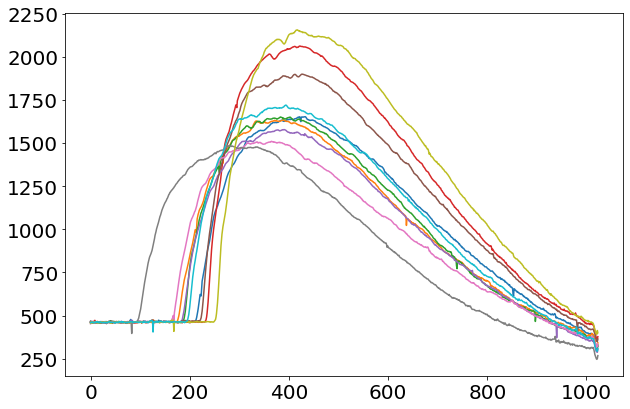

----------------------
CAEN Channel 9 of 16


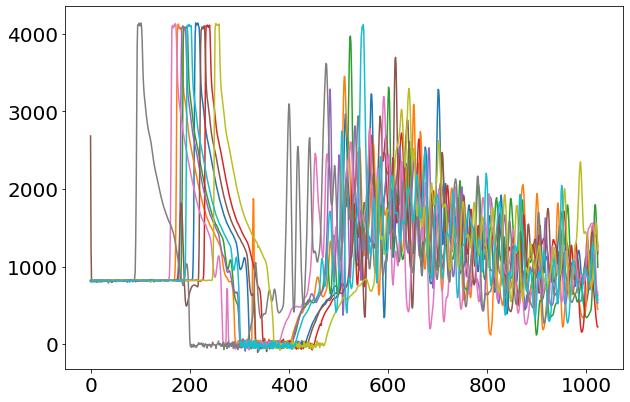

----------------------
CAEN Channel 17 of 16


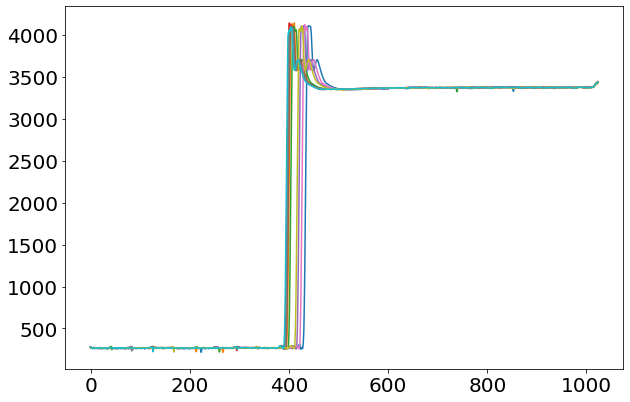

----------------------
total elapsed time 4.5s


In [7]:
starttime = time.time()
nevents = 10
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)
# for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
for ich in [0,8,16]:
    print(f"CAEN Channel {ich+1} of 16")
    for ev in range (nevents):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
print(f"total elapsed time {time.time()-starttime:.1f}s")


In [ ]:
time.sleep(50) # oops

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    print(f"SiPM Channel {ich+1} of 16")
    for ev in range (1000):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
    
t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum390mV_DB1_midleft3x2_10ke_coinc_CAEN_offset0mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum400mV_DB1_midleft3x2_10ke_coinc_CAEN_offset1mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")


In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum420mV_DB1_midleft3x2_10ke_coinc_CAEN_offset2mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum410mV_DB1_midleft3x2_10ke_coinc_CAEN_offset3mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum400mV_DB1_midleft3x2_10ke_coinc_CAEN_offset4mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run06.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run07.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run08.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run09.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run10.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run11.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run12.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run13.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run14.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run15.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run16.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run17.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
beep(2)

In [ ]:
run export_to_html --timestamp